<a href="https://colab.research.google.com/github/Deinbi/Machine__Learning_Alura/blob/main/optimizaci%C3%B3n_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este entrenamiento, trataremos un conjunto de datos utilizando la biblioteca Pandas. También trabajaremos con NumPy. Adicionalmente, generaremos diversas visualizaciones con Matplotlib, Seaborn y Yellowbrick.

De la misma manera, estaremos modelando un modelo de Machine Learning (aprendizaje automático) con Scikit-learn, utilizando datos de retrasos de vuelos de un aeropuerto. A muchas personas les ha sucedido que se presentan imprevistos y retrasos en los vuelos. Esto genera costos tanto para las empresas como para los pasajeros.

La idea es, a través de este proyecto, poder generar un modelo que nos permita prever de forma muy precisa los retrasos en los vuelos, de modo que se pueda optimizar la operación aeroportuaria. De esta manera, todas las personas pasajeras y también las aerolíneas estarán satisfechas al ver una reducción tanto en tiempos de espera como en costos operativos.

#**CLASE 1**

### Importacion de datos

In [61]:
import pandas as pd

datos =  pd.read_csv('/content/flights.csv')
datos.shape

(71175, 11)

### Analisis exploratorio de los datos

Luego, importaremos la biblioteca que utilizaremos para el tratamiento de datos, que es pandas, usando import pandas as pd. Crearemos una variable llamada datos y en ella leeremos el archivo con el método read_csv de pandas. Para ello, copiaremos la ruta del archivo desde los tres puntos al lado del archivo y la pegaremos.

Nuestro conjunto de datos cuenta con 71,175 filas y 11 columnas. Para examinar más de cerca, utilizaremos el método head para visualizar las primeras cinco filas del dataframe.

Las columnas incluyen la identificación del vuelo (flight ID), la aerolínea (airline), el tipo de aeronave (aircraft), si pertenece al espacio Schengen o no, el origen (origin), el horario de llegada (arrival time), el horario de salida (departure time), el día del año (day), si es feriado (is holiday), y nuestra variable respuesta que es el retraso (delay).


In [62]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271



Esta variable delay está en minutos y segundos. Por ejemplo, el vuelo 26 de la aerolínea MM tuvo un retraso de 70 minutos y aproximadamente 12 segundos. Sabemos que son 12 segundos porque multiplicamos el valor decimal por 60. Utilizaremos el método round para mostrar que son aproximadamente 12 segundos.

In [63]:
round(.20*60)

12

Sabemos que son 12 segundos porque multiplicamos el valor decimal por 60. Utilizaremos el método round para mostrar que son aproximadamente 12 segundos.

In [64]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


Para obtener una visión global del conjunto de datos, realizaremos un análisis exploratorio. Utilizaremos el método info con datos.info para conocer los metadatos, que son datos sobre los datos. Esto nos indica que tenemos un total de 11 columnas y 71,175 registros, desde el 0 al 71,174. Cada columna tiene un número consecutivo, comenzando con Flight ID y terminando con Delay.

Todos los registros son no nulos, lo que significa que ya tienen un valor asignado, por lo que no necesitamos preocuparnos por tratar valores nulos en este momento. En cuanto al tipo de datos, observamos que los enteros (int64) incluyen la identificación del vuelo, el día del año y el año.



---

Podemos ir un poco más allá en este análisis exploratorio y utilizar el método de pandas describe, datos.describe, para ver la descripción de la estadística como tal de estos valores, obteniendo algunas medidas de tendencia central y los cuantiles, el desvío estándar y así sucesivamente. A través de este método describe, tomaremos como referencia, por ejemplo, la variable respuesta, que sería el retraso.

In [65]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


El conteo de valores para todos es 71,175. El promedio de retraso, es decir, si sacamos el promedio de retraso de todos los vuelos, sumando todos los minutos y dividiéndolos entre el total de observaciones, es de 12 minutos y alrededor de 30 segundos.

El desvío estándar, o sea, la variación que puede tener desde ese promedio, es de 23 minutos, lo cual es un desvío bastante grande, un margen muy amplio con respecto a ese promedio. Tenemos el valor mínimo de retraso y un valor máximo de retraso.

¿Qué quiere decir este menos 41? Quiere decir que estos vuelos, o este vuelo, esta observación que es el valor mínimo, no se retrasó sino que, por el contrario, salió 41 minutos adelantado. El valor mínimo indica que hay un vuelo dentro de los 71 mil registros que salió 41 minutos adelantado.

Si tomamos nuestro conjunto de datos y ordenamos de menor a mayor todos los valores de retraso, hasta el 25% de los vuelos salieron con algún adelanto. Observamos que el primer cuantil, que es este 25%, dice menos 4.41, lo que equivale a alrededor de 4 minutos y 25 segundos. Esto significa que hasta el 25% de los vuelos han salido no solo dentro del tiempo, sino incluso más rápido de lo esperado.

Si continuamos viendo la secuencia hasta el 50% de los datos, que sería la mediana o el segundo cuantil, ya observamos un atraso de alrededor de 9 minutos y 45 segundos.

Al avanzar un poco más, hasta el 75% de los datos, ya hay un atraso de 27 minutos y alrededor de 40 segundos. Comenzamos a observar que se presenta un atraso considerable, lo cual genera pérdidas y situaciones incómodas tanto para los pasajeros como para la aerolínea y el aeropuerto. El valor máximo de atraso es de hasta 125 minutos, es decir, más de dos horas de atraso.



---
**La idea de observar estas medidas o de hacer este análisis exploratorio es ver cómo se comporta el atraso de los vuelos y generar un modelo de aprendizaje de máquina apoyándonos en los recursos que nos permiten las bibliotecas de Scikit Learn para tener una previsión.**

Si algún vuelo tiene ciertas características, con un margen de error, queremos acercarnos lo máximo posible a cuánto ese vuelo podría potencialmente demorarse. De modo que el plan de estacionamiento o de taxi de las aeronaves quede mejor elaborado, considerando ese margen, para eliminar este tipo de trastornos.

---



También podemos ver no solo las variables numéricas, sino las variables categóricas. Añadimos en nuestra descripción include="O", lo que nos dará también la estadística descriptiva de las variables categóricas.

In [66]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


De las aerolíneas, tenemos tres, y la que más se muestra es la aerolínea BZ con 47,598 ocurrencias de aeronaves.

Tenemos seis tipos distintos de aeronave, siendo el Airbus A320 el más frecuente en nuestros registros, con más de 30,700 registros. En cuanto al espacio Schengen, hay dos posibles clases: Schengen y no Schengen, siendo Schengen la más frecuente, con más de 42,000 ocurrencias.

Por último, la variable de origen, que sería el aeropuerto de origen, tiene 10 aeropuertos desde donde llegan vuelos al aeropuerto que analizamos, siendo el aeropuerto con la sigla TZF el que más vuelos recibe, con 14,162 ocurrencias.

Ya tenemos una idea general de nuestro conjunto de datos. Sin embargo, continuaremos en nuestro próximo video analizando más a fondo esta información y generando algunas visualizaciones para tener una idea más clara sobre lo que estamos tratando.

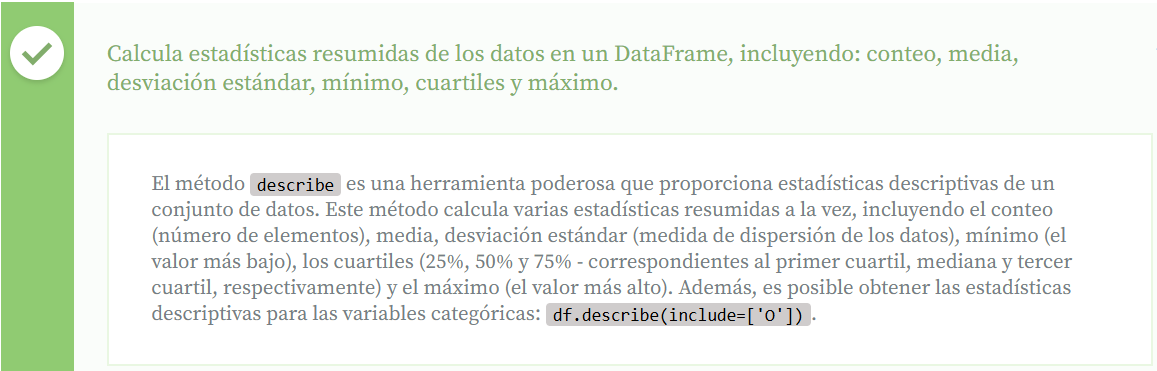

### Analisis grafico

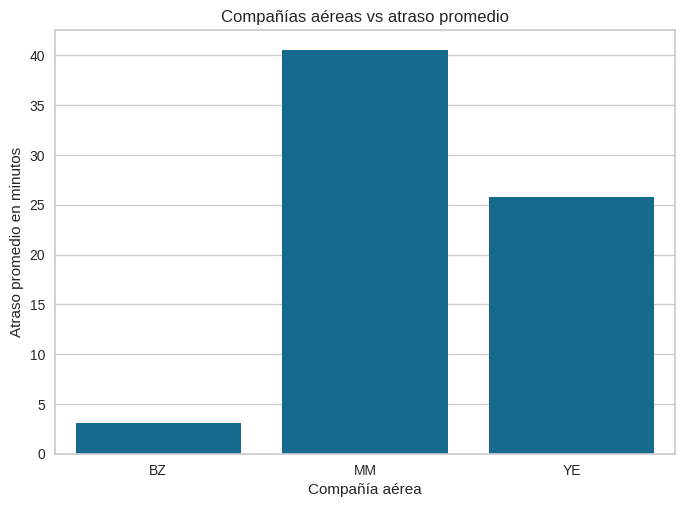

In [67]:
# Importa la biblioteca seaborn para visualización estadística
import seaborn as sns
# Importa matplotlib.pyplot para crear y personalizar gráficos
import matplotlib.pyplot as plt

# Agrupa el DataFrame 'datos' por la columna 'airline' y calcula el promedio de
# los valores en la columna 'delay'
# Luego resetea los índices para convertir el resultado en un DataFrame plano
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
# Crea un gráfico de barras usando seaborn con el promedio de atrasos por aerolínea
sns.barplot(x='airline', y='delay', data=avg_delay)
# Agrega un título al gráfico
plt.title('Compañías aéreas vs atraso promedio')
# Etiqueta el eje X
plt.xlabel('Compañía aérea')
# Etiqueta el eje Y
plt.ylabel('Atraso promedio en minutos')
# Muestra el gráfico en pantalla
plt.show()


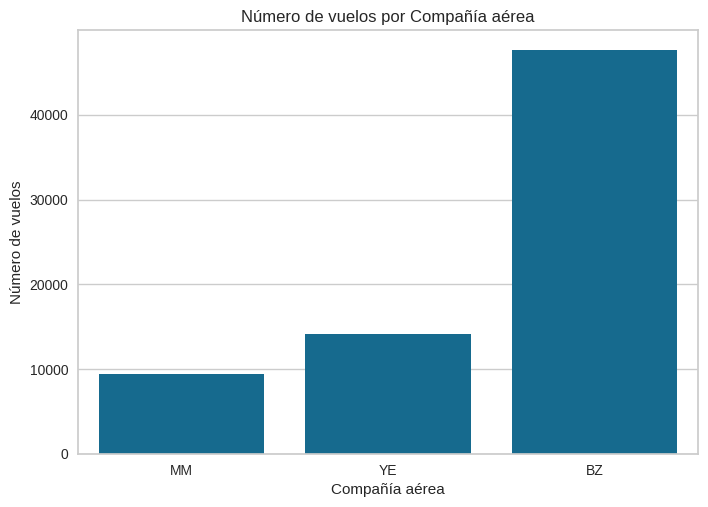

In [68]:
# Crea un gráfico de barras que cuenta cuántas veces aparece cada valor de la columna 'airline' en el DataFrame 'datos'
sns.countplot(data=datos, x='airline')
# Agrega un título al segundo gráfico
plt.title('Número de vuelos por Compañía aérea')
# Etiqueta el eje X
plt.xlabel('Compañía aérea')
# Etiqueta el eje Y
plt.ylabel('Número de vuelos')
# Muestra el segundo gráfico
plt.show()

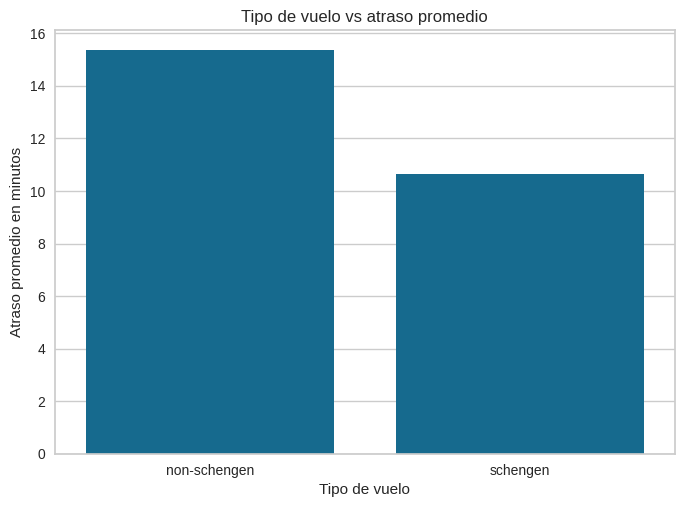

In [69]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen',y='delay',data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()


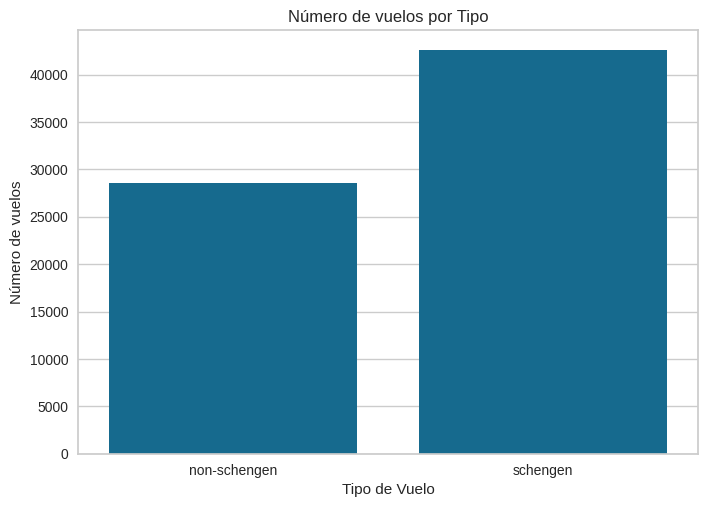

In [70]:
sns.countplot(data=datos, x='schengen')
plt.title('Número de vuelos por Tipo')
plt.xlabel('Tipo de Vuelo')
plt.ylabel('Número de vuelos')
plt.show()

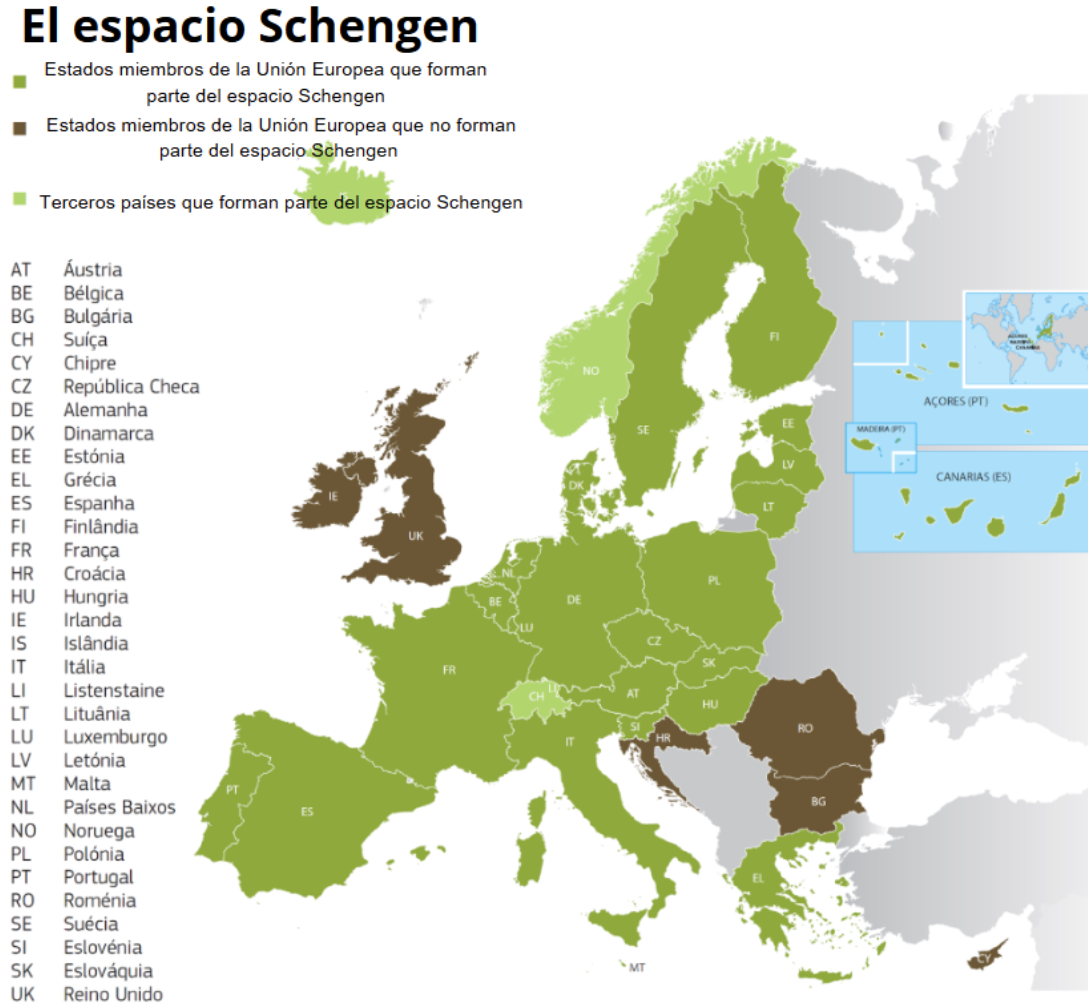!

CTRL+shift+l Cambia la palabra en todo el box

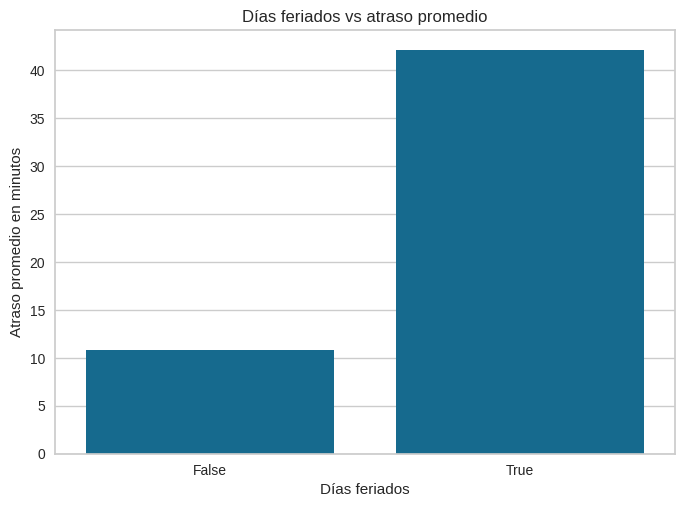

In [71]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday',y='delay',data=avg_delay)
plt.title('Días feriados vs atraso promedio')
plt.xlabel('Días feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()

Además, analizaremos la cantidad de aeronaves que llegan al aeropuerto. Para ello, haremos un countplot y tomaremos los valores de las aeronaves. Estableceremos un orden utilizando datos['aircraft_type'].value_counts().index, que ordena de mayor a menor cantidad. Esto nos organiza todas las aeronaves, y las almacenaremos en order.



In [72]:
datos['aircraft_type'].value_counts().index

Index(['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175',
       'Boeing 737', 'Boeing 777'],
      dtype='object', name='aircraft_type')

Antes de continuar, mostraremos qué devuelve este gráfico. Nos devuelve un índice indicando que las aeronaves más numerosas son Airbus A320, seguidas de Airbus A330, y así sucesivamente.



In [73]:
order = datos['aircraft_type'].value_counts()
order

,count
aircraft_type,
Airbus A320,30778
Airbus A330,16654
Boeing 787,9606
Embraer E175,7098
Boeing 737,4722
Boeing 777,2317


Si solo queremos ver los valores, podemos ejecutar la celda para verificar que están en el mismo orden: Airbus A320, Airbus A330, y el último es el Boeing 777. Este método nos permite tener a mano el orden de las aeronaves.



In [74]:
order = datos['aircraft_type'].value_counts().index

En el countplot, colocaremos en x el tipo de aeronave (aircraft_type) y el orden será el mismo.

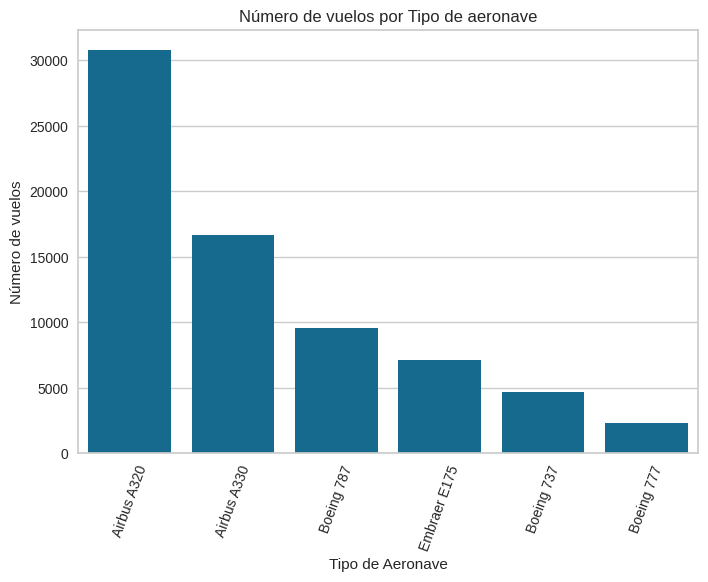

In [75]:
sns.countplot(data=datos, x='aircraft_type',order=order)
plt.title('Número de vuelos por Tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Número de vuelos')
plt.show()

Al graficar, podemos observar la cantidad de vuelos con respecto a las aeronaves, obteniendo información relevante para comprender el comportamiento de los vuelos en este aeropuerto.


En el próximo vídeo, analizaremos cómo están distribuidos nuestros datos para entender el comportamiento de la variable de respuesta, que es el atraso.

Para ello, nos apoyaremos en un instrumento llamado histograma, que nos permite analizar la frecuencia de nuestros diferentes valores. Nos concentraremos en los que más nos interesan, como el horario de llegada de los vuelos, el horario de salida y, principalmente, el atraso en minutos.

### Analizando la distribucion de los datos

<Axes: xlabel='arrival_time', ylabel='Count'>

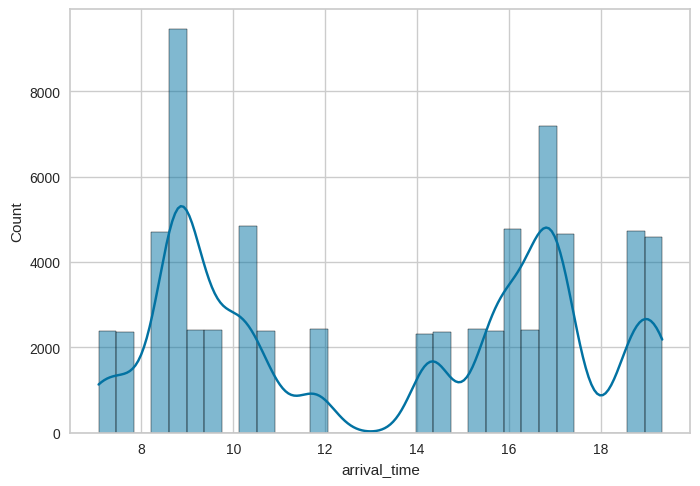

In [76]:
sns.histplot(data=datos,x='arrival_time',kde=True)

<Axes: xlabel='arrival_time', ylabel='Count'>

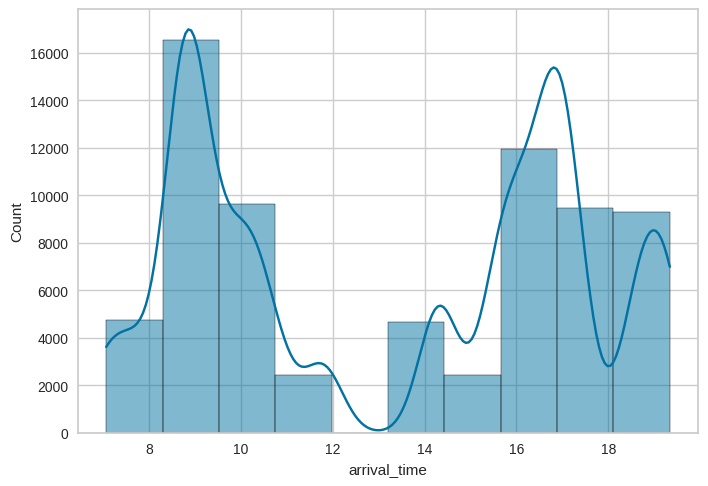

In [77]:
sns.histplot(data=datos,x='arrival_time',kde=True,bins=10)

Para adecuar el ancho de las barras, hay una formula que se puede consultar en el siguiente enlace:

https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule

Aca lo vamos a llevar a cabmo con numpy y lo vamos a implementar en una funcion para que sea llamada mas adelante:


In [78]:
import numpy as np

def ancho_bin(df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75-q25
  ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
  return ancho

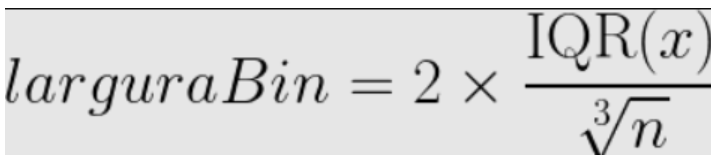

<Axes: xlabel='arrival_time', ylabel='Count'>

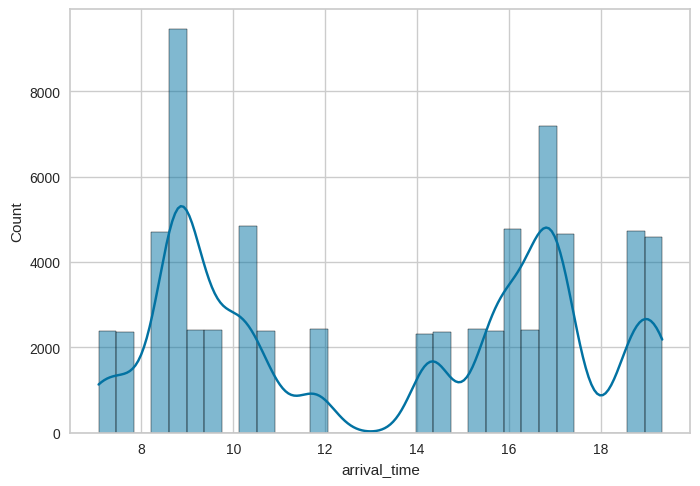

In [79]:
binwidth = ancho_bin(datos,'arrival_time')
sns.histplot(data=datos,x='arrival_time',kde=True,binwidth=binwidth)

<Axes: xlabel='departure_time', ylabel='Count'>

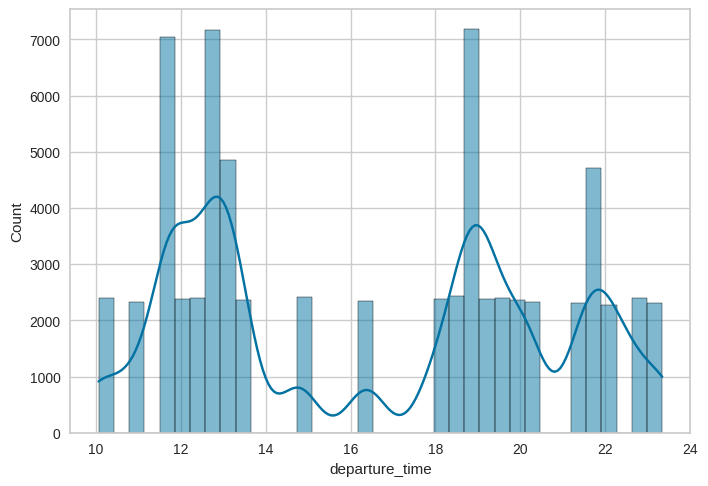

In [80]:
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos,x='departure_time',kde=True,binwidth=binwidth)

Si comparamos con el horario de llegada, notamos que la mayoría de las observaciones están alrededor de las 9 de la mañana, y el horario de salida alrededor de las 11, casi al mediodía, y después a la 1 de la tarde.

En la tarde, el horario de llegada es alrededor de las 5, y la salida es alrededor de las 7 de la noche.

**Vemos una distribución bimodal, con una moda aquí y otra al otro lado, mostrando una distribución muy semejante.**

*Lo que nos interesa es el gráfico de distribución de la variable respuesta, que son los retrasos en los vuelos.*

---



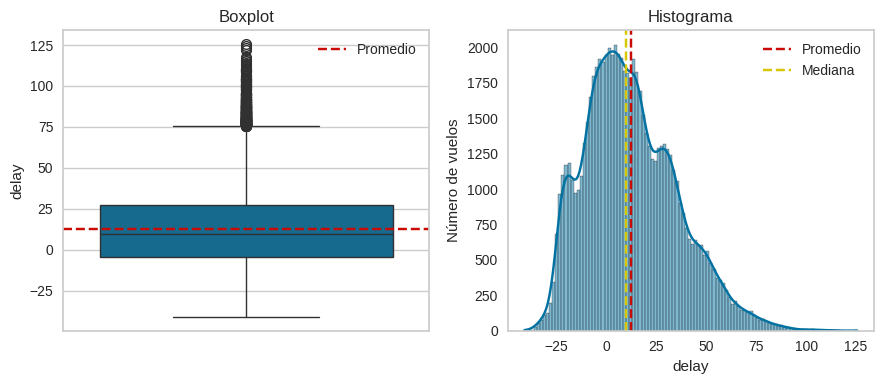

In [81]:
# Calcula el promedio de la columna 'delay' y lo guarda en la variable 'atraso_promedio'
atraso_promedio = datos['delay'].mean()
# Calcula la mediana de la columna 'delay' y la guarda en la variable 'atraso_mediana'
atraso_mediana = datos['delay'].median()
# Crea una figura con dos subgráficos (1 fila, 2 columnas) de tamaño 9x4 pulgadas
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
# Dibuja un boxplot (diagrama de caja) de la columna 'delay' en el primer subgráfico (a la izquierda)
sns.boxplot(data=datos, y='delay', ax=ax[0])


# Establece el título del primer subgráfico
ax[0].set_title('Boxplot')
# Dibuja una línea horizontal en el valor del promedio de delay, de color rojo y estilo de línea punteada
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
# Agrega una leyenda al primer subgráfico
ax[0].legend()
# Calcula el ancho de bin (intervalo) a usar en el histograma usando una función personalizada llamada 'ancho_bin'
binwidth = ancho_bin(datos, 'delay')
# Dibuja un histograma de la columna 'delay' en el segundo subgráfico, con densidad KDE y binwidth personalizado
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True, binwidth=binwidth)
# Etiqueta el eje Y del histograma
plt.ylabel('Número de vuelos')
# Elimina las líneas de la grilla del gráfico (opcional, estético)
plt.grid(False)


# Establece el título del segundo subgráfico
ax[1].set_title('Histograma')
# Dibuja una línea vertical en el valor del promedio de delay, de color rojo y línea punteada
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label='Promedio')
# Dibuja una línea vertical en el valor de la mediana de delay, de color amarillo y línea punteada
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label='Mediana')
# Agrega la leyenda al segundo subgráfico
ax[1].legend()


# Ajusta automáticamente los elementos de la figura para que no se superpongan
plt.tight_layout()
# Muestra los gráficos en pantalla
plt.show()

A la izquierda, tendremos nuestro boxplot para observar la distribución, y a la derecha, el histograma, que también nos ayuda en esta observación. Un gráfico de violín, por ejemplo, nos permite ver la distribución y, en su interior, el boxplot. Sin embargo, debido a la dificultad de interpretación del gráfico de violín, optamos por el boxplot y el histograma.

En el boxplot, observamos que la mediana está alrededor de 10 minutos y el promedio alrededor de 12 minutos. Recordando nuestro método describe en pandas, la mediana era de aproximadamente 9 minutos y 45 segundos, y el promedio de 12 minutos y 30 segundos.

El valor mínimo era de 41 minutos de adelanto del vuelo y el máximo de 125 minutos. Estos 125 minutos son considerados outliers o observaciones atípicas. El valor máximo que realmente consideramos en el boxplot es de alrededor de 75 minutos de atraso, y el mínimo de 44 minutos, que fue el adelanto del vuelo.

La distribución en el histograma muestra que el promedio y la mediana están muy cercanos, lo que indica una distribución cercana a la normal. Con este conjunto de datos, en nuestra próxima clase, procederemos a generar nuevos atributos para crear nuestro modelo predictivo de atrasos. Nos vemos en la próxima clase.

---



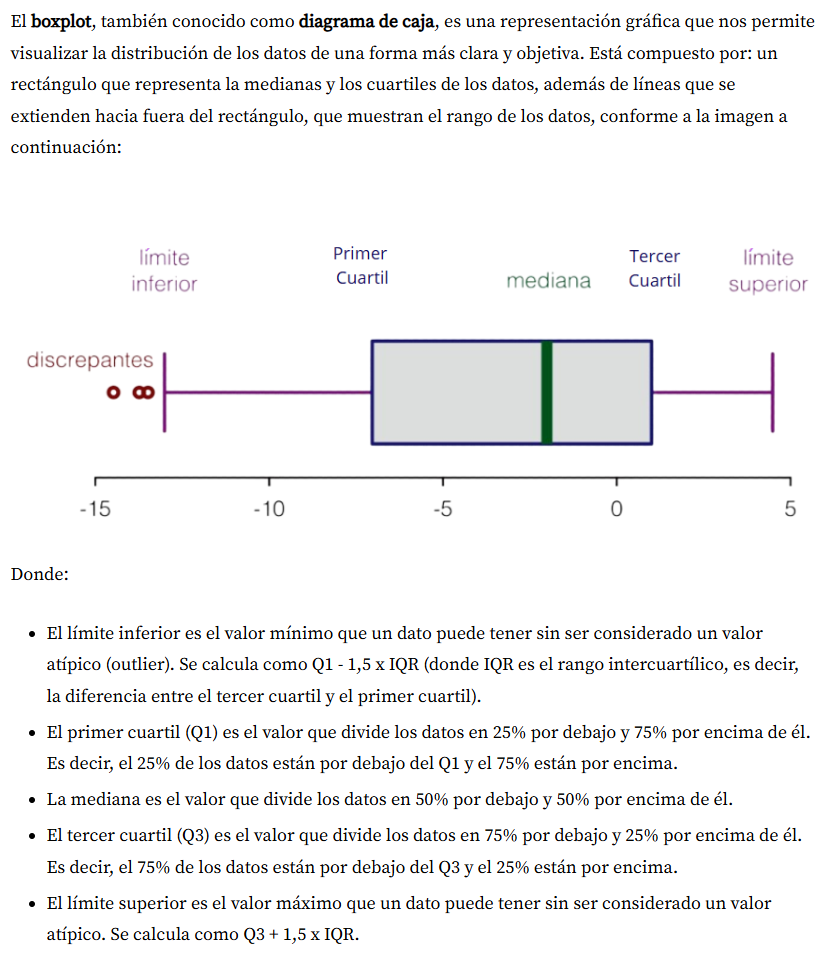

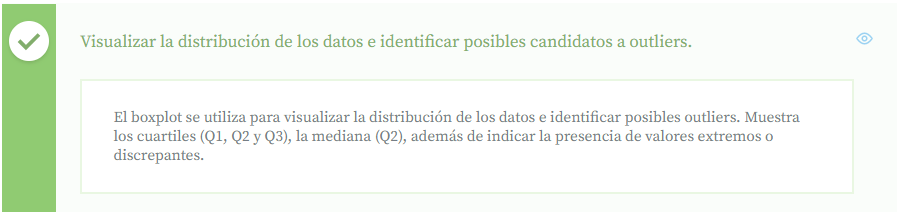

Analizar las estadísticas descriptivas de los datos;
Obtener información relevante de los datos, como la cantidad de datos nulos y el tipo de las columnas;
Construir el análisis gráfico de los datos;
Construir la visualización gráfica de la distribución de los datos.

#**CLASE 2**

### Creando nuevas columnas con valiosa información

In [82]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

 Observamos que tenemos la columna Day (día) y la columna Year, pero no tenemos una columna que tenga que ver con la fecha. Entonces, podríamos crear la columna Fecha a partir de estas dos columnas.

Si revisamos la parte superior, cuando estábamos haciendo el análisis de los metadatos, notamos que tanto Day como Year son enteros. Podemos aprovechar esta situación para hacer algunos ajustes.

Adicionalmente, observamos en la estadística descriptiva que el valor mínimo de día es cero, equivalente al primero de enero, y el máximo es 364, que sería el último día del año. En cuanto a los años, tenemos valores desde 2010 hasta 2022.

Lo que haremos es crear en nuestro DataFrame una columna que llamaremos date. Tomaremos el año y lo convertiremos en string con astype(str), y lo concatenaremos con un guion y también con el día.

Sin embargo, como comienza en el día cero, no podemos tratar este valor así; debemos comenzar a partir del día uno para poder utilizar un método de la biblioteca datetime que nos permita generar una fecha a partir de este formato.

Vamos a visualizar cómo se ve nuestro DataFrame con datos.head, mostrando solo dos filas. Notamos que ya tenemos la columna date. Deberíamos eliminar la columna datos, por lo que usaremos datos.drop. Aquí colocaremos columns y dentro de columns la columna datos. Con esto, ya hemos generado la nueva estructura de datos.

#### Formateando fechas

In [83]:
datos['date'] = datos['year'].astype(str) +'-'+(datos['day']+1).astype(str)
datos['date'] = pd.to_datetime(datos['date'],format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


Ya tenemos la columna date directamente. Esto lo dejamos así; ni siquiera debíamos haberlo hecho de esta manera, pero fue necesario debido a un error con el nombre de la columna.

Ahora que la columna date está corregida, tenemos el año 2010 y el día 1, que corresponde al primer día del año. Ahora podemos tomar esta columna datos.date y utilizar el método de pandas to_datetime.

Ahora que tenemos nuestra columna date, avancemos un poco más y generemos una columna que nos permita determinar si es fin de semana o no. Es muy interesante; tomaremos nuestro DataFrame y crearemos una columna que llamaremos isWeekend. Ya tenemos isHoliday, ahora añadiremos isWeekend.

La columna isWeekend será igual a datos. De datos, tomaremos la columna date y, utilizando el método de datetime, aplicaremos weekday y isin. Esto verificará si el día de la semana está dentro del sexto y séptimo día.

Los días comienzan a partir de cero, por lo que el día cinco representa sábado y el seis representa domingo; el lunes sería el cero. Así, sabemos que estamos aislando sábado y domingo para identificar si es fin de semana.

#### Identificando dias de la semana

Los días comienzan a partir de cero, por lo que el día cinco representa sábado y el seis representa domingo; el lunes sería el cero. Así, sabemos que estamos aislando sábado y domingo para identificar si es fin de semana.

In [84]:
datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
datos['day_name'] = datos['date'].dt.day_name()
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
35102,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,150,2016,True,21.571610,2016-05-30,False,Monday
70301,23,YE,Embraer E175,schengen,TCY,18.801235,21.801235,306,2022,False,4.118198,2022-11-03,False,Thursday
8763,2,BZ,Airbus A320,schengen,ZQO,19.196804,22.196804,219,2011,False,0.483497,2011-08-08,False,Monday
7859,4,BZ,Airbus A330,schengen,TCY,11.781391,14.781391,158,2011,False,-8.335653,2011-06-08,False,Wednesday
52100,21,BZ,Boeing 737,schengen,FJB,7.065594,10.065594,188,2019,False,40.928714,2019-07-08,False,Monday


Además, crearemos una variable llamada dayName en datos. Con el mismo método de datetime, utilizaremos day_name, que nos devuelve el nombre del día de la semana. Vamos a realizar un datos.head o datos.sample para tomar una muestra de cinco registros de nuestro conjunto de datos.

Observamos que ya tenemos isWeekend, que quedará como booleano. Si es fin de semana, será verdadero para el día que fue sábado; perfecto, los otros días no son fin de semana. Los días son viernes (Friday), martes (Tuesday), miércoles (Wednesday), y la fecha está tal como la especificamos.

Hemos añadido nuevos atributos a partir únicamente del día y el año. Sin embargo, aún tenemos muchas variables categóricas, y para poder modelar con machine learning, es necesario que las codifiquemos.



---



---

Para saber más: ¿qué es el feature engineering?




El feature engineering es un concepto fundamental en el campo de la ciencia de datos y el aprendizaje automático, y desempeña un papel crucial en el proceso de desarrollo de modelos predictivos y analíticos. Esta técnica implica la creación, transformación y selección de variables, también conocidas como "features", a partir de los datos brutos disponibles, con el fin de mejorar el rendimiento de los modelos. Pero, ¿qué serían features?

¿Qué son las features?

Las features son las variables o atributos que un modelo de machine learning utiliza para hacer predicciones o clasificaciones. Representan la información que el modelo tiene a su disposición para aprender patrones en los datos. Por ejemplo, si estamos construyendo un modelo para predecir el precio de una casa, las features pueden incluir el número de habitaciones, la superficie en metros cuadrados, la ubicación geográfica, la proximidad a escuelas, entre otras.

La importancia del Feature Engineering:

Mejora el rendimiento del modelo:

Elegir las features correctas y transformarlas adecuadamente puede resultar en modelos más precisos y eficientes. Features bien diseñadas pueden capturar información relevante y eliminar ruido en los datos.

Reduce la dimensionalidad:

En conjuntos de datos con muchas features, la dimensionalidad de los datos puede convertirse en un problema. El feature engineering puede ayudar a reducir la cantidad de features, manteniendo solo aquellas que son realmente informativas para el modelo.


Técnicas de Feature Engineering:


Existen varias técnicas de feature engineering, incluyendo:

Creación de features:

Esto implica la creación de nuevas features basadas en las existentes. Por ejemplo, combinar las features de superficie y valor de una propiedad para crear una feature que represente el valor por metro cuadrado de esa propiedad. O, si tienes datos de fecha y hora, puedes crear una nueva característica que represente el día de la semana. Esto puede ser útil porque tal vez haya patrones que ocurren en días específicos de la semana.


Transformación de features:

Se pueden aplicar funciones matemáticas a las features existentes para hacerlas más adecuadas para el modelo. Ejemplos incluyen aplicar logaritmos o escalar valores para reducir la escala en la que se encuentra la variable.


Selección de features:

No todas las features son igualmente importantes. La selección de features implica identificar y mantener solo las más relevantes para el problema en cuestión.


---

---


### Codificando parametros (Features encoding)

In [85]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

Los modelos de Machine Learning funcionan mejor cuando tenemos los datos codificados, es decir, variables numéricas. Sin embargo, en muchos casos nuestras variables no son numéricas, sino de otro tipo, como cadenas de caracteres o booleanas. Para abordar esto, vamos a utilizar nuevamente la información de nuestros metadatos para identificar qué tipo de columnas tenemos.

Si no deseamos ver estas advertencias, podemos importar la biblioteca warnings y utilizar warnings.filterwarnings con la opción "ignore". Esto ignorará las advertencias. Importamos la biblioteca, ejecutamos nuevamente y ya no veremos las advertencias sobre las modificaciones futuras del código.

In [86]:
import warnings

warnings.filterwarnings('ignore') #Para ignorar advertencias en codigo de python, proximo a ser obsoleto.

Tenemos, por ejemplo, la columna "Aerolínea", "Tipo de aeronave", "Espacio Schengen" y "Origen". Todas ellas son cadenas de caracteres que debemos codificar. También tenemos otras variables de tipo booleano, como IsWeekend y IsHoliday. Aunque "Schengen" es de tipo String (Objeto), solo tiene dos categorías: Schengen o no Schengen. Vamos a tomar estas variables inicialmente y realizar las modificaciones necesarias.

Primero, trabajaremos con las que tienen dos categorías. Para los datos de "Schengen", tomaremos nuestra columna y utilizaremos el método replace. Usaremos un diccionario donde la primera llave será "non Schengen" (cuando no sea espacio Schengen) y le asignaremos el valor 0. Cuando sea "Schengen", le asignaremos el valor 1.

Para las otras dos variables booleanas, simplemente copiaremos estos valores. Tomaremos IsHoliday, lo copiaremos y lo pegaremos en lugar de "non Schengen". Así, el valor False será reemplazado por 0 y True por 1. Aplicaremos el mismo diccionario para IsWeekend.

In [87]:
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})


Luego, realizaremos un datos.sample para tomar únicamente tres muestras. Así, ya habremos cambiado IsHoliday, IsWeekend y "Schengen". Ahora tenemos variables numéricas.

In [88]:
datos.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
24495,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,173,2014,0,-14.351394,2014-06-23,0,Monday
42734,26,MM,Airbus A320,0,TCY,8.885071,10.885071,293,2017,0,50.024054,2017-10-21,1,Saturday
3318,15,BZ,Airbus A330,0,FJB,16.571894,19.571894,221,2010,0,-4.048051,2010-08-10,0,Tuesday


Aún tenemos variables de tipo objeto como "Airline", "Aircraft", "Origin" y "DayName", que acabamos de crear. Vamos a crear una lista llamada categóricas y colocaremos estas variables: "Airline", "Aircraft Type", "Origin" (aeropuerto de origen) y "DayName".

Utilizaremos un método de pandas que nos permite codificar nuestras variables con ceros y unos de forma numérica: get_dummies. Usaremos pd.get_dummies y especificaremos nuestro conjunto de datos, las columnas que queremos codificar (columns=categóricas) y el tipo de dato (dtype) que será entero. Ejecutaremos esto sin almacenarlo para observar qué sucede.

El método toma las columnas y, por ejemplo, si el día es viernes, asigna 1 a ese registro y 0 al resto de los días de la semana. Generamos muchos atributos, pero no hay inconveniente, ya que el objetivo es codificar nuestras variables.

In [89]:
categoricas = ['airline','aircraft_type','origin','day_name']
pd.get_dummies(data=datos,columns=categoricas, dtype=int).head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0


Copiamos este código y creamos una nueva variable llamada datos_codificados para almacenar nuestros dummies. Realizamos un datos_codificados.sample de cinco muestras.

Así, tenemos cinco muestras de nuestros datos codificados y todo está listo para avanzar a la próxima etapa, que es realizar una limpieza de nuestro conjunto de datos, ya que pueden haber variables que no son interesantes para el desarrollo de nuestro modelo.

In [90]:
datos_codificados =pd.get_dummies(data=datos,columns=categoricas, dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
9060,24,1,9.668655,12.668655,239,2011,0,8.356225,2011-08-28,1,...,0,0,0,0,0,0,1,0,0,0
66683,1,0,15.496519,18.496519,65,2022,0,13.241447,2022-03-07,0,...,0,0,0,0,1,0,0,0,0,0
59345,23,1,18.801235,21.801235,306,2020,0,14.079091,2020-11-02,0,...,1,0,0,0,1,0,0,0,0,0
28901,30,1,8.923441,12.923441,101,2015,0,-13.753847,2015-04-12,1,...,0,0,0,0,0,0,1,0,0,0
4238,14,1,7.708301,11.708301,282,2010,0,-11.042180,2010-10-10,1,...,0,0,1,0,0,0,1,0,0,0


Ya tenemos un DataFrame codificado, con todas nuestras variables casi listas para introducirlas al modelo de Machine Learning (aprendizaje automático).

Sin embargo, es necesario que analicemos un poco mejor las variables que estamos utilizando, porque hay casos en los cuales las variables pueden tener comportamientos muy semejantes y pueden acabar perjudicando nuestro modelado.

¿A qué nos referimos con ello? Notamos que tanto el horario de llegada como el horario de salida tenían un comportamiento muy semejante. Si observamos la gráfica en la parte superior, cuando estábamos viendo la distribución de estos horarios, por ejemplo, el horario de llegada presentaba una distribución bimodal, y el horario de salida, DepartureTime, de la misma forma. Entonces, se parecen mucho, pero matemáticamente, ¿cómo podemos validar lo que estamos diciendo?

#### Metodo de las correlaciones

Podemos utilizar un método de pandas, que es el método de las correlaciones. Vamos a tomar nuestras variables ArrivalTime y DepartureTime. Básicamente, un mapa de correlación nos dice cómo se relaciona una variable, o un número definido de variables, con respecto a otras.

La correlación puede ser positiva o negativa, y varía de menos uno a uno. De cero a menos uno tenemos las correlaciones negativas. ¿Qué quiere decir esto? Que la variación es inversamente proporcional. En otras palabras, mientras una variable crece, la otra decrece en la misma proporción.

Un ejemplo muy sencillo: mientras más se demora un vuelo en salir, menos satisfacción tienen los clientes. Entonces, hay una correlación negativa.

Ahora bien, si tomamos una correlación positiva, sería de cero a uno. Aplicándolo a nuestro caso, mientras menos tiempo se demora la aerolínea en preparar sus aeronaves, menos será la demora. Entonces, ambas variables se comportan de manera similar, creciendo o decreciendo juntas. Esa es la idea detrás de la correlación.

In [91]:
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


Vamos a ver la correlación entre el horario de llegada y el horario de salida. Observamos que existe una correlación de casi 100%.

La correlación es muy fuerte. El hecho de incluir estas dos variables puede sesgar nuestro modelo. Debemos escoger solo una de ellas. Además, generamos nuevas variables.





---

Si revisamos nuevamente nuestros metadatos, notamos que estamos viendo datos codificados. En nuestros datos codificados, ya hemos creado todas estas variables a partir de las que eran cadenas de caracteres.

In [92]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

#### Borrando informacion que no necesitamos

Esta variable date, por ejemplo, la utilizamos para saber si era fin de semana o no. Entonces, ya no la necesitamos.

Tampoco necesitamos la variable year.

Podemos removerlas, así como la de identificación, ya que el número de identificación no nos proporciona ningún patrón.

**No existe ningún patrón que podamos extraer de ahí**, porque todas son identificaciones diferentes. Esto no tiene relación con comportamientos para este modelo en particular.

Considerando esto, vamos a proceder de la siguiente manera. Crearemos una variable que llamaremos df. Tomaremos los datos codificados y realizaremos un drop, especificando entre paréntesis las columnas que vamos a eliminar. Entonces, escribimos columns= y colocamos en una lista las columnas a eliminar.

La primera columna será flightID. Eliminaremos DepartureTime, ya que tanto el horario de llegada como el de salida tienen una correlación muy alta. Escogemos una de ellas, el horario de salida, DepartureTime. También eliminaremos día, año y fecha (date). ¿Por qué las eliminamos? Porque no estamos realizando un análisis temporal con series temporales. Simplemente estamos previendo atrasos considerando las demás variables.

In [93]:
df = datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
41606,1,19.196804,0,-9.875086,0,1,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
58036,0,8.794147,0,31.475376,0,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
5358,0,17.041281,0,71.018989,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
60849,0,8.885071,0,46.092323,0,0,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
12834,0,16.571894,0,12.648696,1,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
8937,1,7.065594,0,41.819022,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
44801,1,9.668655,0,6.618056,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
9826,1,18.801235,0,26.570416,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
50459,0,15.496519,0,7.416851,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
26920,1,14.258911,0,-2.524039,0,1,0,0,1,0,...,0,1,0,0,1,0,0,0,0,0


De los datos codificados, eliminamos estas variables y tomamos una muestra con df.sample. Esta vez, tomaremos 10 muestras. Al presionar Shift-Enter, observamos que tenemos estas 10 muestras y todas nuestras variables completamente codificadas.

En nuestra próxima clase, con nuestro DataFrame completamente tratado, con nuestras features creadas y codificadas, procederemos a iniciar nuestro modelado con Machine Learning. ¡Nos vemos pronto!

#### OneHotEncoder de Scikit-Learn

Aplica la codificación dummy en el código de la clase utilizando el OneHotEncoder de Scikit-Learn en lugar del get_dummies de la biblioteca pandas.

Para utilizar el OneHotEncoder en lugar del get_dummies de la biblioteca Pandas podemos hacerlo de la siguiente manera:

In [94]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

categoricas = ['airline','aircraft_type','origin','day_name']

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),
    categoricas),
    remainder='passthrough')

datos = one_hot_enc.fit_transform(datos)
datos = pd.DataFrame(datos, columns=one_hot_enc.get_feature_names_out())
datos

,onehotencoder__airline_BZ,onehotencoder__airline_MM,onehotencoder__airline_YE,onehotencoder__aircraft_type_Airbus A320,onehotencoder__aircraft_type_Airbus A330,onehotencoder__aircraft_type_Boeing 737,onehotencoder__aircraft_type_Boeing 777,onehotencoder__aircraft_type_Boeing 787,onehotencoder__aircraft_type_Embraer E175,onehotencoder__origin_AUZ,...,remainder__flight_id,remainder__schengen,remainder__arrival_time,remainder__departure_time,remainder__day,remainder__year,remainder__is_holiday,remainder__delay,remainder__date,remainder__is_weekend
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,364,2022,1,25.677277,2022-12-31,1
71171,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,17,0,16.718722,21.718722,364,2022,1,52.624348,2022-12-31,1
71172,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,7,1,8.564949,13.564949,364,2022,1,56.16708,2022-12-31,1
71173,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5,1,9.344097,12.344097,364,2022,1,56.758844,2022-12-31,1


Analizando el código anterior paso a paso:

1 - from sklearn.compose import make_column_transformer

Este es un import del método make_column_transformer de la biblioteca sklearn.compose. Este método se usa para aplicar transformaciones específicas a columnas específicas de un DataFrame.

2 - from sklearn.preprocessing import OneHotEncoder

Este es un import del OneHotEncoder de la biblioteca sklearn.preprocessing. Este es el método que realmente realiza la codificación one-hot.

3 - categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

Aquí, estamos definiendo una lista de nombres de columnas que queremos transformar usando la codificación one-hot, que son las mismas definidas utilizando el get_dummies.

4 - one_hot_enc = make_column_transformer((OneHotEncoder(handle_unknown='ignore'), categoricas), remainder='passthrough')

Aquí, estamos creando un ColumnTransformer que aplica el OneHotEncoder a las columnas especificadas en categoricas. El argumento handle_unknown='ignore' significa que el OneHotEncoder ignorará cualquier categoría desconocida que pueda aparecer durante la transformación. El argumento remainder='passthrough' significa que cualquier columna que no esté especificada para la transformación será pasada a través sin cambios.

5 - datos = one_hot_enc.fit_transform(datos)

Aquí, estamos aplicando la transformación al DataFrame datos. El método fit_transform ajusta el transformador a los datos y luego transforma los datos.

6 - datos = pd.DataFrame(datos, columns=one_hot_enc.get_feature_names_out())

Aquí, estamos convirtiendo los datos transformados de nuevo a un DataFrame. También estamos definiendo los nombres de las columnas para que sean los nombres de características de salida del ColumnTransformer.

#**CLASE 3**

Vamos a iniciar con nuestro DataFrame completamente tratado para el modelado con Machine Learning (aprendizaje automático). Para ello, debemos establecer en primer lugar una línea base o referencia, conocida como Baseline. Esta Baseline será nuestro punto de partida y compararemos todo nuestro modelado con ella, ya que la idea es mejorarla.

Nos apoyaremos en gran medida en la biblioteca Scikit-Learn. Esta biblioteca es muy útil para trabajar con Machine Learning. Estamos trabajando con regresión, y existen diversos tipos de modelos de regresión que podemos utilizar, así como clasificación, clustering (agrupamiento) y selección de modelos.

La documentación de Scikit-Learn es muy completa, y recomendamos consultarla. Dejaremos el enlace disponible en nuestro cuaderno para que lo tengas a mano y sepas dónde consultar los documentos de todos los ejercicios que realizaremos.

https://scikit-learn.org/stable/

Como mencionamos, vamos a crear una Baseline. Para esta Baseline, no es necesario que sea el mejor modelo; podemos crear un modelo dummy (básico), que no generaliza muy bien.

Para ello, utilizaremos DummyRegressor de sklearn.dummy. Este regresor realiza la regresión de manera básica. También utilizaremos train_test_split de sklearn.model_selection, que nos permitirá separar nuestro DataFrame en datos de prueba y datos de entrenamiento.

In [95]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X = df.drop(['delay'],axis=1)
y = df['delay']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

baseline = DummyRegressor()
baseline.fit(X_train,y_train)

DummyRegressor()

En la misma celda, definiremos X como nuestras variables independientes, tomando de nuestro DataFrame todas las variables excepto la columna delay, ya que delay es nuestra variable de respuesta. Así, X contendrá todas las columnas excepto delay, y Y será precisamente nuestra variable delay.

Procederemos a segregar nuestro modelo con X_train, X_test, Y_train y Y_test, en ese orden, utilizando train_test_split. Estableceremos un tamaño de muestra de prueba (test_size) de 0.3, lo que significa que probaremos con el 30% de nuestro DataFrame.

Para poder reproducir nuestro modelado, debemos establecer un estado de aleatoriedad, ya que todos estos modelos son pseudoaleatorios. Utilizaremos random_state=42, pero puedes elegir el número que desees para generar este estado de pseudoaleatoriedad.

Crearemos nuestro modelo de Baseline, al que llamaremos baseline, utilizando DummyRegressor. Ajustaremos nuestros datos a este modelo con baseline.fit, utilizando X_train y Y_train. Una vez entrenado nuestro modelo, procederemos a evaluarlo utilizando métricas.



---

Importaremos de sklearn.metrics las métricas mean_squared_error, mean_absolute_error y r2_score. Estas métricas nos permitirán medir el error de nuestro modelo. El coeficiente de determinación (r2_score) es especialmente importante, ya que indica qué tanto las variables independientes logran explicar la variable de respuesta.

In [96]:
# Importa tres métricas de evaluación de modelos de regresión desde scikit-learn:
# - mean_squared_error: error cuadrático medio
# - mean_absolute_error: error absoluto medio
# - r2_score: coeficiente de determinación R^2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Genera predicciones usando un modelo de base (dummy) previamente entrenado, aplicado a los datos de prueba X_test
y_pred_dummy = baseline.predict(X_test)

# Define una función llamada 'calcular_regresion' que toma dos parámetros:
# - y_test: valores reales (observados)
# - y_pred: valores predichos por el modelo
def calcular_regresion(y_test, y_pred):

    # Calcula el error cuadrático medio entre los valores reales y los predichos
    rmse = mean_squared_error(y_test, y_pred)
    # Calcula el error absoluto medio
    mae = mean_absolute_error(y_test, y_pred)
    # Calcula el R², que mide el grado de ajuste del modelo (1 es ajuste perfecto)
    r2 = r2_score(y_test, y_pred)

    # Crea un diccionario con las métricas redondeadas a 4 decimales
    metricas = {
        'RMSE': round(rmse**(1/2), 4),  # Toma la raíz cuadrada del MSE para obtener el RMSE
        'MAE': round(mae, 4),          # Redondea el MAE
        'R2': round(r2, 4)             # Redondea el R²
    }
    # Devuelve el diccionario con las métricas calculadas
    return metricas

Vamos a crear nuestra variable yPredDummy. Aquí simplemente tomamos baseline.predict y colocamos X_test. Hacemos esa predicción y definimos una función que llamaremos calcularRegresión, la cual recibirá los valores reales y los valores predichos.

Dentro de nuestra función, colocaremos el rootMeanSquaredError, utilizando Y_test y la y predicha por nuestro modelo. No queremos que lo ponga al cuadrado, sino que deje el valor sin elevar al cuadrado para que siempre quede como un número positivo.

También tenemos el error absoluto promedio, mAe, que sería mean_absolute_error con los mismos parámetros: Y_test y y predicha. Además, queremos el R2, que sería r2_score con Y_test y y predicha.

Vamos a crear un diccionario llamado métricas y colocaremos primero RmSe con su valor, luego mAe con su valor, y finalmente R2 con su valor. Estos números se devolverán con varias cifras decimales, así que les daremos un tratamiento especial, limitándolos a 4 cifras decimales.

Devolvemos nuestras métricas. Ya creamos nuestra función, ahora generamos una variable llamada resultadosBaseLine, que será calcularRegresión con Y_test y el valor de nuestro DummyRegressor. Visualizamos resultadosBaseLine.

In [97]:
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
resultados_baseline

{'RMSE': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

El error cuadrado medio es de 23.16 minutos, el error absoluto medio es de 18.5 minutos, y el coeficiente de determinación es de cero. Este modelo no está generalizando de manera correcta.



---



---
Para saber más: métricas utilizadas en regresión
 Siguiente pregunta

Durante el video, se presentaron algunas de las métricas más comunes para evaluar modelos de regresión, como RMSE, MAE y R2. Junto con estas métricas, existen diversas otras que pueden ser bastante útiles durante la evaluación de un modelo de regresión. A continuación, podrás encontrar algunas de las métricas más utilizadas y sus traducciones en español:

Mean squared error - MSE (Error Cuadrático Medio);
Mean absolute error - MAE (Error Absoluto Medio);
Root Mean Squared Error - RMSE (Raíz Cuadrada del Error Cuadrático Medio);
Mean Squared Logarithmic Error - MSLE (Error Logarítmico Cuadrático Medio); y
Mean Absolute Percentage Error - MAPE (Porcentaje del Error Absoluto Medio).
Mean squared error - MSE
El Mean Squared Error (MSE), o Error Cuadrático Medio, es una métrica ampliamente utilizada para evaluar el rendimiento de un modelo de aprendizaje automático. Esta métrica calcula la media de los errores cuadrados, donde cada error es la diferencia entre el valor previsto por el modelo y el valor real. La elevación al cuadrado da mayor peso a los errores mayores, lo que puede ser útil cuando esos errores son particularmente indeseables. El MSE se define matemáticamente como:



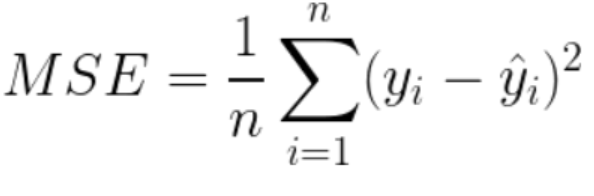

En esta fórmula, "n" representa el número de observaciones o muestras, "y_i" es el valor real de la i-ésima observación y "ŷ_i" es el valor predicho para la i-ésima observación. El MSE se calcula tomando la diferencia entre los valores reales y los valores predichos, elevando al cuadrado, sumando todas estas diferencias al cuadrado y, a continuación, dividiendo por el número de observaciones "n".

Para evaluar la calidad de un modelo usando el MSE, cuanto más cerca de 0 esté el valor del MSE, mejor estará el modelo en predecir los valores deseados. Esto se debe a que un MSE de 0 indica que no hay diferencia entre los valores previstos y los valores reales, es decir, el modelo está haciendo predicciones perfectas.

Aunque el MSE es una métrica útil, vale la pena mencionar que tiene la desventaja de dar más peso a los outliers debido al cuadrado de cada término. Esto puede ser indeseable en muchos casos, llevando a los investigadores a usar alternativas, como el error absoluto medio (MAE).

La documentación de scikit-learn tiene información que ofrece más detalles sobre esta métrica en “mean_squared_error”.

Mean absolute error - MAE

El Error Absoluto Medio (MAE) es una medida de error común utilizada en modelos de regresión. Se calcula tomando la media de los valores absolutos de los errores. En otras palabras, para cada punto de datos, primero calculamos el error (la diferencia entre el valor predicho y el valor real), tomamos el valor absoluto de ese error (para asegurar que todos los errores sean positivos), y luego calculamos la media de todos estos errores absolutos. El MAE se define como:



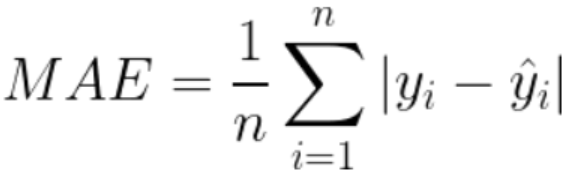

En esta ecuación, "n" representa el número de observaciones o muestras, "y_i" es el valor real de la i-ésima observación y "ŷ_i" es el valor predicho para la i-ésima observación. El MAE se calcula tomando la diferencia absoluta entre los valores reales y los valores predichos para todas las observaciones, sumando estas diferencias absolutas y, a continuación, dividiendo por el número de observaciones "n".

El MAE es similar a la Métrica del Error Cuadrático Medio (MSE), pero en lugar de elevar los errores al cuadrado, simplemente toma el valor absoluto de los errores. Esto hace que el MAE sea menos sensible a outliers que el MSE, ya que los errores grandes no se amplifican por el cuadrado.

Al evaluar modelos de regresión con el MAE, un valor menor indica un modelo más preciso. En otras palabras, cuanto menor sea el MAE, mejor será el modelo en predecir el valor correcto para nuevos datos. El MAE tiene un límite inferior de 0, que indica un modelo perfecto (es decir, todas las predicciones son exactas).

Cabe destacar que, aunque el MAE es una métrica útil, no debe ser la única métrica utilizada para evaluar el rendimiento de un modelo de regresión. Otras métricas, como el MSE, la Raíz Cuadrada del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación (R2), también deben ser consideradas para obtener una evaluación completa de la capacidad de un modelo para hacer predicciones precisas.

La documentación de scikit-learn ofrece más detalles sobre esta métrica en “MAE”.

Root Mean Squared Error - RMSE


La Raíz Cuadrada del Error Cuadrático Medio (RMSE) es una métrica de evaluación comúnmente utilizada en modelos de regresión, que es esencialmente la raíz cuadrada del MSE (Error Cuadrático Medio). El RMSE se calcula tomando la raíz cuadrada de la media de los errores cuadrados, que son las diferencias entre los valores previstos y los valores reales, elevadas al cuadrado. Matemáticamente, el RMSE se define como:

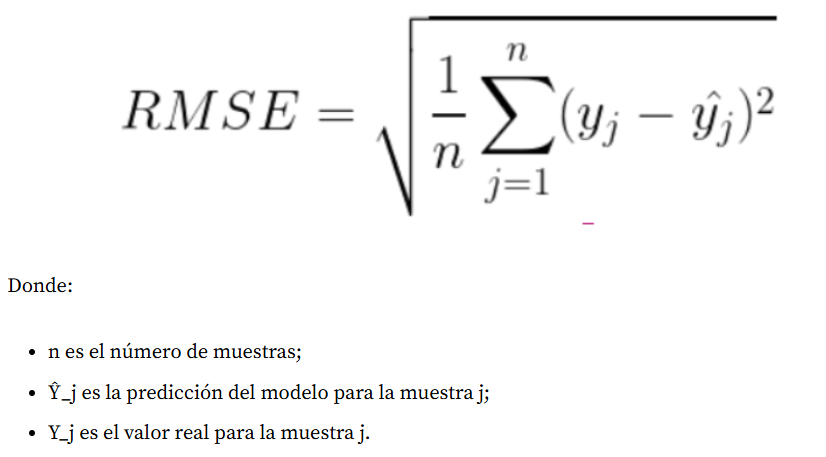

El RMSE es una medida de la dispersión de los residuos (errores de predicción) y, al igual que el MSE, penaliza los errores mayores de forma más severa que los errores menores, debido al hecho de elevar al cuadrado las diferencias. Esto lo hace particularmente sensible a grandes errores.

Un valor menor de RMSE indica un mejor ajuste del modelo a los datos, es decir, las predicciones del modelo están más cerca de los valores reales. Es importante resaltar que, aunque el RMSE es una métrica útil, no debe ser la única métrica considerada al evaluar la calidad de un modelo de regresión.

Puedes acceder a la documentación de scikit-learn para saber más sobre esta métrica: metrics.mean_squared_error.

Mean Squared Logarithmic Error - MSLE
El Error Logarítmico Cuadrático Medio es una métrica de evaluación utilizada en problemas de predicción donde la escala de los valores objetivo o de las predicciones varía significativamente y los errores relativos son más importantes que los errores absolutos. El MSLE mide el error cuadrático medio entre los logaritmos naturales de los valores reales y los logaritmos naturales de las predicciones. Matemáticamente, se puede definir el MSLE de la siguiente manera:

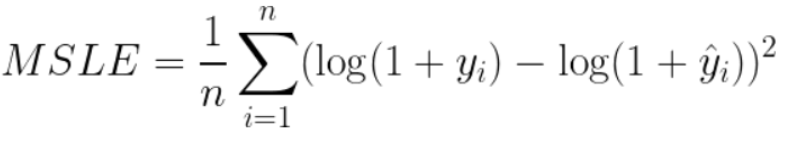

Donde "n" representa el número de observaciones o muestras, "y_i" es el valor real de la i-ésima observación y "ŷ_i" es el valor predicho para la i-ésima observación. El MSLE se calcula tomando el logaritmo natural de los valores reales y predichos sumados a 1, calculando la diferencia entre estos logaritmos, elevando al cuadrado, sumando todas estas diferencias al cuadrado y, a continuación, dividiendo por el número de observaciones "n".

El principal punto de enfoque de esta métrica es medir la diferencia relativa entre los valores esperados y los predichos por el modelo, es decir, verifica la diferencia porcentual entre ellos. De modo que, pequeñas diferencias entre valores pequeños son tratadas igualmente a grandes diferencias entre valores grandes, a diferencia de lo que ocurre en el MSE, como se muestra en el siguiente ejemplo:

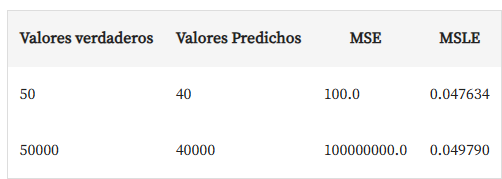

Esto nos muestra que las grandes diferencias entre los valores reales y predichos tienen poca variación en el resultado final de la métrica. Por lo tanto, esta métrica se utiliza más cuando no deseamos que grandes errores sean significativamente más penalizados que errores pequeños.

Para saber más sobre esta métrica y cómo utilizarla, puedes acceder a la documentación de scikit-learn: metrics.mean_squared_log_error.

Mean Absolute Percentage Error - MAPE
El Mean Absolute Percentage Error es muy similar al Mean Absolute Error - MAE, con la diferencia de que mide la precisión como un porcentaje y puede ser calculado como el porcentaje del MAE para cada muestra. El MAPE se utiliza mucho en problemas de regresión, ya que proporciona una interpretación bastante intuitiva sobre el error relativo. La definición del MAPE es:

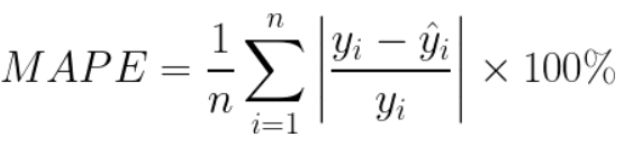

Donde "n" representa el número de observaciones o muestras, "y_i" es el valor real de la i-ésima observación, "ŷ_i" es el valor predicho para la i-ésima observación, y el MAPE se calcula como la media de los porcentajes absolutos de las diferencias entre los valores reales y los valores predichos en relación con los valores reales. El resultado se multiplica por 100% para expresar el error como un porcentaje.

El MAPE se utiliza frecuentemente como una métrica de error para evaluar la precisión de las predicciones en problemas de predicción y se expresa como un porcentaje del error medio absoluto en relación con los valores reales. Para saber más sobre esta métrica y cómo utilizarla, puedes acceder a la documentación de scikit-learn: metrics.mean_absolute_percentage_error.



---



---



#### DummyRegressor

Manos a la obra: otras estrategias para el DummyRegressor

Como se indica en la documentación, observamos que hay varias enfoques disponibles para implementar el DummyRegressor a través del parámetro 'strategy'. Durante el curso, optamos por la estrategia 'mean (media)', en la cual la salida corresponde a la media del conjunto de datos utilizado para el entrenamiento. Sin embargo, hasta el momento, no hemos explorado las demás estrategias disponibles.

Por lo tanto, sugerimos que pruebes las otras estrategias presentes en el parámetro strategy del DummyRegressor.

Para evaluar los modelos necesitamos utilizar algunas métricas, por lo tanto, vamos a utilizar la función definida durante el curso:

In [119]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas_regresion(y_test, y_pred):

    rmse = mean_squared_error(y_test, y_pred) ** 0.5  # sin usar squared=False
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {
        'Raíz del Error Cuadrático Medio': round(rmse, 4),
        'Error Absoluto Medio': round(mae, 4),
        'R2 Score': round(r2, 4)
    }

    return metricas

Para calcular las métricas de acuerdo con las diferentes estrategias, un ejemplo de código se describe a continuación:

In [120]:
from sklearn.dummy import DummyRegressor

estrategias = ["mean", "median", ("quantile", 0.25), ("constant", 10.0)]

resultados = {}

for estrategia in estrategias:
    if isinstance(estrategia, tuple):
        estrategia, valor = estrategia
        if estrategia == "quantile":
            model_dummy = DummyRegressor(strategy=estrategia, quantile=valor)
        else:
            model_dummy = DummyRegressor(strategy=estrategia, constant=valor)
    else:
        model_dummy = DummyRegressor(strategy=estrategia)

    model_dummy.fit(X_train, y_train)

    y_pred_dummy = model_dummy.predict(X_test)

    metricas = calcular_metricas_regresion(y_test, y_pred_dummy)

    resultados[estrategia] = metricas

for estrategia, metricas in resultados.items():
    print(f"Estrategia: {estrategia}")
    for metrica, valor in metricas.items():
        print(f"{metrica}: {valor}")
    print("\n")

Estrategia: mean
Raíz del Error Cuadrático Medio: 23.2241
Error Absoluto Medio: 18.6127
R2 Score: -0.0


Estrategia: median
Raíz del Error Cuadrático Medio: 23.4038
Error Absoluto Medio: 18.4891
R2 Score: -0.0155


Estrategia: quantile
Raíz del Error Cuadrático Medio: 28.7943
Error Absoluto Medio: 22.0382
R2 Score: -0.5372


Estrategia: constant
Raíz del Error Cuadrático Medio: 23.3699
Error Absoluto Medio: 18.4893
R2 Score: -0.0126






```
Estrategia: mean
Raíz del Error Cuadrático Medio: 23.2124
Error Absoluto Medio: 18.625
R2 Score: -0.0001

Estrategia: median
Raíz del Error Cuadrático Medio: 23.4093
Error Absoluto Medio: 18.5151
R2 Score: -0.0171

Estrategia: quantile
Raíz del Error Cuadrático Medio: 28.8715
Error Absoluto Medio: 22.1284
R2 Score: -0.5472

Estrategia: constant
Raíz del Error Cuadrático Medio: 23.3724
Error Absoluto Medio: 18.5142
R2 Score: -0.0139
```



El DummyRegressor es una clase de scikit-learn que permite la creación de un modelo simple de referencia (o baseline) para comparación con modelos más complejos. Este modelo no toma en cuenta los datos de entrada y hace predicciones basadas en una estrategia simple especificada.

Las estrategias utilizadas en este código son: "mean", "median", ("quantile", 0.25), ("constant", 10.0). Cada una de estas estrategias define cómo el DummyRegressor hace sus predicciones:

"mean": predice la media de los valores de entrenamiento.
"median": predice la mediana de los valores de entrenamiento.
"quantile": predice un cuantil específico de los valores de entrenamiento. En el caso de este código, se utiliza el cuantil 0.25.
"constant": predice un valor constante especificado. En el caso de este código, se utiliza el valor 10.0.
El código recorre cada una de estas estrategias en un bucle, entrenando un DummyRegressor con la estrategia correspondiente y evaluando su desempeño utilizando un conjunto de métricas de regresión. Las métricas son calculadas por la función calcular_metricas_regresion.

Los resultados se almacenan en un diccionario, donde la clave es la estrategia utilizada y el valor es otro diccionario que contiene las métricas calculadas. Por último, el código imprime los resultados para cada estrategia.



---



---



## Entrenando con bosques aleatorios

####RandomForestRegressor

Ya hemos establecido una línea base (Baseline), utilizando un DummyRegressor. La idea era que generalizara de la manera menos inteligente posible para que pudiéramos mejorar nuestro modelo. Esto es completamente válido y normal al trabajar con Machine Learning: siempre establecemos una línea base y, a partir de ahí, comenzamos a mejorar.

Para nuestro problema, utilizaremos bosques aleatorios, conocidos como Random Forest, que es un modelo más robusto y con el cual mejoraremos considerablemente el resultado de nuestra línea base. Importamos el RandomForestRegressor de sklearn.ensemble.

Una vez que tenemos nuestro regresor de Random Forest, lo siguiente es crear nuestro modelo. Lo llamaremos simplemente modelo y utilizaremos el RandomForestRegressor. Este regresor tiene un parámetro que debemos ajustar, que es la profundidad máxima.

Inicialmente, estableceremos este parámetro en 5. También definiremos un estado de aleatoriedad para poder reproducir nuestro modelo, utilizando una semilla, que en este caso será 42. Es importante mantener este mismo número de estado de pseudoaleatoriedad a lo largo del desarrollo.

Con nuestro modelo listo, procederemos a ajustar nuestros datos con fit(xTrain, yTrain). Después de esto, realizaremos la predicción con yPred = modelo.predict(xTest).

Para evaluar el resultado, calcularemos la regresión con calcularRegresión, que recibe yTest y yPred. Esto nos permitirá ver los resultados de nuestro modelo de Random Forest. Este modelo crea varios árboles de decisión y encuentra la mejor combinación para obtener el mejor resultado al realizar una previsión, en este caso, nuestra variable de retrasos.

In [121]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(max_depth=5, random_state=42)
modelo.fit(X_train,y_train)
ypred = modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test,ypred)
resultados_rf

{'RMSE': 13.7348, 'MAE': 11.0177, 'R2': 0.6502}

Observamos que nuestro modelo generalizó mucho mejor, con un Root Mean Square Error de 13 minutos, mejorando de 23 minutos a 13 minutos. El error medio absoluto pasó de 18 minutos a 11 minutos, y el coeficiente de determinación es de casi 65%. Todo esto se logró estableciendo una profundidad de 5 en nuestro modelo.

Para visualizar estos resultados de manera gráfica, utilizaremos una biblioteca interesante llamada Yellowbrick. Vamos a ver un Error Plot que nos permite observar gráficamente cómo está generalizando nuestro modelo. Copiaremos un fragmento de código de un Quick Method y lo refinaremos lógicamente para nuestros propósitos.

Entonces, no necesitamos el modelo lazo, lo eliminamos. El Train Test Split tampoco es necesario, así que lo quitamos. El Data Set también lo eliminamos, ya que no lo necesitamos.

Solo requerimos la predicción del error, por lo que no necesitamos hacer la división aquí de X-Train, ni cargar el Data Set, ni el modelo. Simplemente eliminamos todo esto. Aquí sería el modelo directamente.

Procedemos a graficar, podemos poner un punto y coma aquí, y ejecutamos nuestra celda. Esto nos permitirá visualizar cómo está generalizando nuestro modelo.

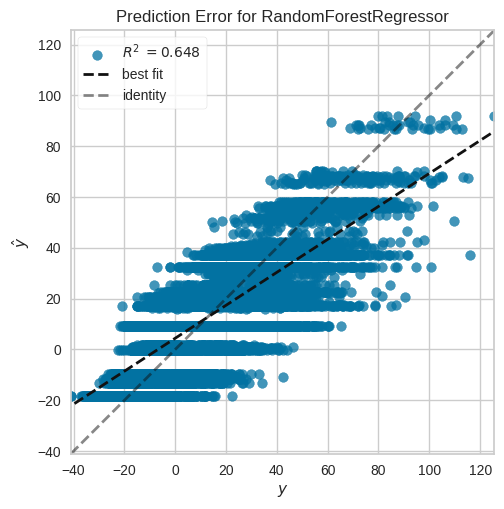

In [99]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test);

La predicción de error para este regresor de Random Forest muestra que el mejor ajuste está representado por la línea negra. La línea de identidad, que es nuestra gráfica de identidad del modelo, es la que se muestra aquí.

El mejor ajuste es lo que debemos alcanzar, y por eso obtenemos este resultado en R² con las características del modelo. La recta que mejor se ajusta a nuestro conjunto de datos es la que está en negro más oscuro, mientras que la que aparece en gris es la obtenida con nuestro modelo al pasar el parámetro MaxDepth igual a 5. Es una forma interesante de visualizar.



---



#### Analisis de residuos de nuetra regresion

Además, tenemos un gráfico que nos permite ver los residuos, es decir, cuánto realmente está generalizando nuestro modelo.

Vamos a utilizar de Yellowbrick este análisis de residuos. En la documentación, encontramos que esta gráfica se obtiene a partir de un snippet.

Vamos a revisar la documentación para ver el análisis que genera y, de la misma forma, utilizaremos el Quick Method.

Copiamos todas estas líneas de código y las pegamos. No necesitamos el Random Forest ni el T-Split, así que los eliminamos.

Solo necesitamos el gráfico de residuos, y aquí también eliminamos estos códigos innecesarios.

La visualización no será con RandomForestRegressor, sino con el modelo.

Perfecto, le pasamos estos parámetros y ejecutamos nuestra celda.

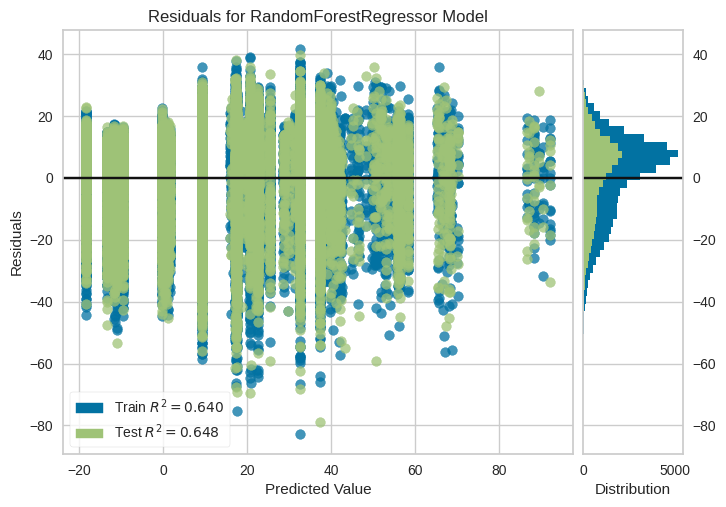

In [100]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo, X_train, y_train, X_test, y_test);

Hay un entrenamiento disponible en la plataforma de regresión, donde se explica más detalladamente en qué consisten los residuos. Básicamente, los residuos son la diferencia entre mis observaciones, los datos de entrenamiento, y la línea trazada por mi modelo.

Esta línea se traza de manera que minimice la distancia de cada observación hacia ella, y esos son los residuos. Queremos que los datos de prueba tengan un comportamiento lo más similar posible a los obtenidos con el entrenamiento.

**Observamos que el comportamiento de prueba fue muy cercano al de entrenamiento. La idea de observar esta distribución es que, aunque el coeficiente de determinación del entrenamiento fue del 64%, al probarlo, llegó casi al 65%.**

Esto indica que el modelo está generalizando relativamente bien sin mejoras adicionales, ajustes de hiperparámetros o refinamientos. Sin embargo, no es suficiente

. Es necesario aplicar otras técnicas, como la validación cruzada, que nos permita tomar diversas muestras de nuestro conjunto de datos para verificar si el comportamiento se mantiene a lo largo de las distintas muestras o si el resultado fue producto de la aleatoriedad del modelo. Esto lo veremos en nuestro próximo video.

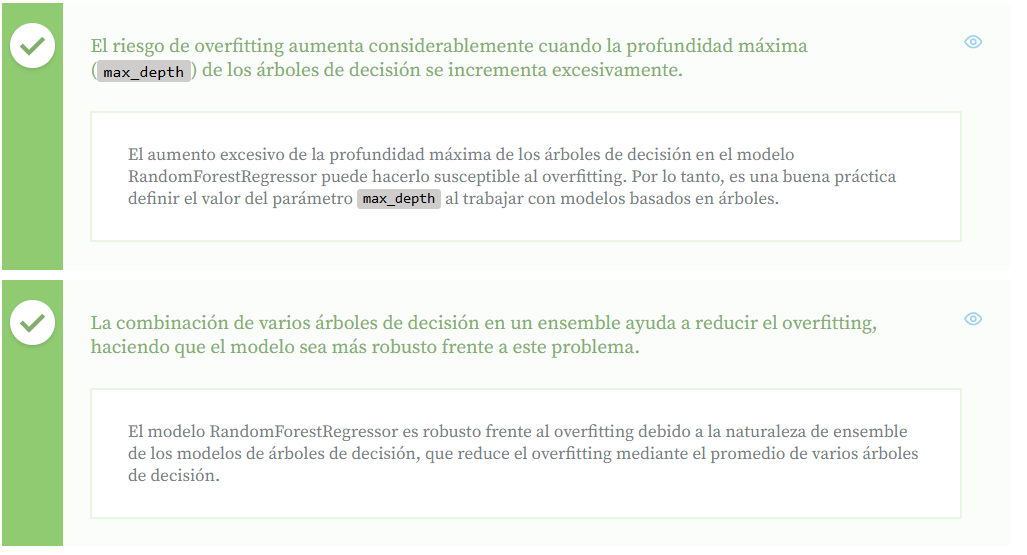

## Realizando cross validations

Hemos mencionado que realizamos un modelado utilizando bosques aleatorios, pero únicamente empleamos un mismo conjunto de datos para entrenamiento y otro para prueba.

Por lo tanto, no sabemos si nuestro modelo está generalizando adecuadamente con cualquier combinación de datos de entrenamiento y prueba. La idea de realizar una validación cruzada es precisamente dividir nuestro conjunto de datos en varias partes y tomar diferentes secciones de este conjunto para entrenar y probar.

Para ello, contamos con dos recursos de Scikit-Learn que son KFold. En la documentación, el recurso se llama KFold y se encuentra en Model Selection.

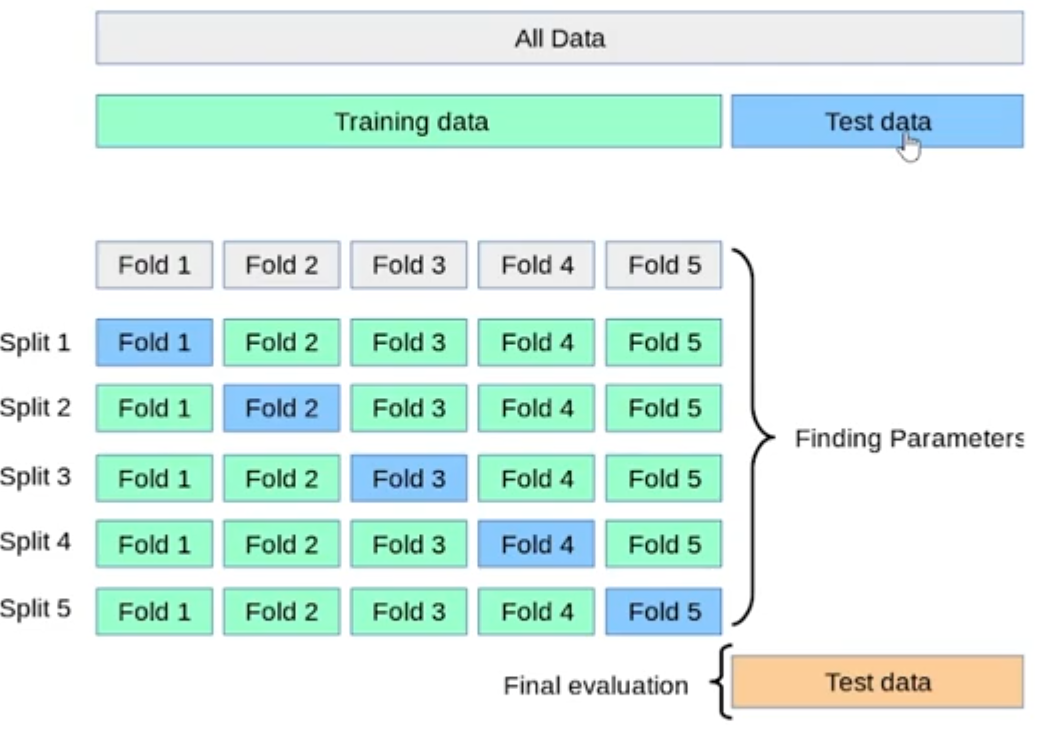

Es un recurso muy sencillo, y en la guía del usuario se muestra cómo funciona. En la documentación, se explica que se toma todo el conjunto de datos y, por ejemplo, para el caso que tenemos aquí, se utiliza el 80% para entrenamiento (representado en verde) y el 20% para prueba (representado en azul).

Se realizarán cinco divisiones, dependiendo de la cantidad de folds que estimemos. Para este caso, son cinco, y el primer doblez será para prueba, mientras que el restante será para entrenamiento.

En el segundo caso, el primer conjunto de datos, el 20%, será para entrenamiento, el siguiente para prueba y el otro 60% para entrenamiento. En el tercer caso, el 40% inicial será para entrenamiento, el otro 20% para prueba y el 40% final para entrenamiento, y así sucesivamente.

De esta manera, realizaremos diversas combinaciones tanto para entrenar como para validar nuestro modelo.

Entonces, es muy sencillo. Utilizamos la clase KFold de Model Selection de Scikit-Learn. Vamos a copiar este código y pegarlo. Importamos directamente de este código: from sklearn.model_selection import KFold.

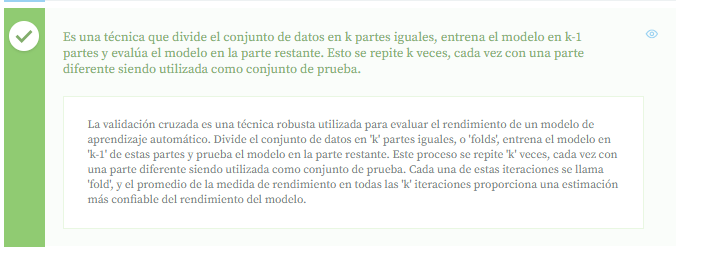

In [131]:
# Importa KFold (para validación cruzada manual) y cross_validate (para evaluar modelos) desde scikit-learn
from sklearn.model_selection import KFold, cross_validate

# Define un diccionario con las métricas a evaluar en la validación cruzada
# - 'RMSE' usará el error cuadrático medio negativo (porque sklearn devuelve negativos por convención)
# - 'MAE' usará el error absoluto medio negativo
# - 'R2' usará el coeficiente de determinación R²
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

# Define un objeto KFold para realizar validación cruzada con 5 particiones
# - shuffle=True mezcla los datos antes de dividirlos (importante para aleatoriedad)
# - random_state asegura reproducibilidad (misma división cada vez que se ejecuta)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Realiza la validación cruzada con el modelo especificado
# - modelo: el modelo de regresión ya definido (por ejemplo, LinearRegression())
# - X_train, y_train: datos de entrenamiento
# - scoring: métrica(s) definidas previamente
# - cv: estrategia de validación cruzada (en este caso, KFold con 5 particiones)
cv_results = cross_validate(modelo, X_train, y_train, scoring=scoring, cv=cv)

# Muestra los resultados obtenidos en la validación cruzada (devuelve un diccionario con métricas por pliegue)
cv_results

{'fit_time': array([2.15768647, 1.45215416, 1.39866018, 1.47048116, 1.42828321]),
 'score_time': array([0.06354213, 0.06136942, 0.06301475, 0.06492567, 0.06247497]),
 'test_RMSE': array([-13.77718826, -14.05339748, -13.79045867, -13.87796861,
        -13.93413937]),
 'test_MAE': array([-11.08511305, -11.30420621, -11.05338951, -11.14275742,
        -11.1767512 ]),
 'test_R2': array([0.64625769, 0.62409069, 0.64550538, 0.640844  , 0.6345765 ])}

In [128]:
-cv_results['test_RMSE']

array([13.77718826, 14.05339748, 13.79045867, 13.87796861, 13.93413937])

In [129]:
-cv_results['test_MAE']

array([11.08511305, 11.30420621, 11.05338951, 11.14275742, 11.1767512 ])

In [130]:
-cv_results['test_R2']

array([-0.64625769, -0.62409069, -0.64550538, -0.640844  , -0.6345765 ])

Con nuestro scoring definido, podemos visualizar nuestros resultados.

Este proceso demorará un poco porque ejecutará todas las combinaciones posibles y calculará las métricas: root mean squared error, mean absolute error y el coeficiente de determinación.

Al finalizar la ejecución, veremos el tiempo que tomó calcular los resultados con cada combinación.

Una vez obtenidos los resultados, no nos enfocaremos en el tiempo que tomó ajustar el modelo ni en los puntajes, sino en los resultados.

La idea es que haya consistencia en esos resultados.

Observamos que para el root mean squared error, el valor fue de -13.76, -13.86, -13.96, -13.85, -13.98, mostrando una variación leve pero consistente.

En nuestro modelo, fue de 13.74, lo que indica consistencia y un buen resultado.

Para el error promedio absoluto, los valores fueron -11, -11.13, -11.20, -11.14, -11.25, y en nuestro modelo fue -11.02, lo cual es excelente.

Por último, el coeficiente de determinación fue 64.5%, 63.74%, 63.5%, 64% y 63.4%, mientras que en nuestro modelo fue 64.77%.

Esto indica que realizando esta validación cruzada, realmente hay consistencia en nuestros resultados.

En nuestra próxima clase, avanzaremos un poco más en nuestro modelado, ya que hasta aquí no hemos ajustado ningún hiperparámetro.

Lo único que hicimos fue darle una profundidad a nuestro estimador, pero no más.

Nuestro estimador tiene muchos más hiperparámetros, los cuales veremos en nuestra próxima clase.



#**CLASE 4**

In [102]:
len(df.columns)

31

In [103]:
importances = modelo.feature_importances_

In [104]:
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
4,airline_BZ,53.03
2,is_holiday,14.59
7,aircraft_type_Airbus A320,10.07
8,aircraft_type_Airbus A330,5.76
12,aircraft_type_Embraer E175,4.59
1,arrival_time,3.60
11,aircraft_type_Boeing 787,2.64
20,origin_TCY,2.09
15,origin_CSF,1.60
19,origin_PUA,1.03


In [105]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

resultados

,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7587,13.7497,13.7498,13.7477,13.7479
MAE,14.9620,12.0605,11.0422,11.0285,11.0280,11.0261,11.0262
R2,0.3388,0.5718,0.6471,0.6476,0.6476,0.6477,0.6477


In [106]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = range(10,16)

for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

resultados

,10,11,12,13,14,15
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476


In [107]:
selected_features = feature_importances['Features'].values[:13]
X_selected_features = X[selected_features]
X_selected_features

,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,aircraft_type_Boeing 787,origin_TCY,origin_CSF,origin_PUA,origin_TZF,day_name_Friday,origin_MWL
0,0,0,1,0,0,8.885071,0,1,0,0,0,1,0
1,0,0,1,0,0,8.939996,0,1,0,0,0,1,0
2,1,0,0,0,1,18.635384,0,0,0,0,1,1,0
3,1,0,0,1,0,15.967963,0,0,0,0,0,1,0
4,1,0,0,1,0,16.571894,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1,1,0,0,1,18.635384,0,0,0,0,1,0,0
71171,1,1,0,1,0,16.718722,0,0,0,0,0,0,0
71172,0,1,0,0,0,8.564949,1,0,0,0,1,0,0
71173,1,1,1,0,0,9.344097,0,0,0,0,0,0,0


In [108]:
X_train,X_test,y_train,y_test = train_test_split(X_selected_features,y,random_state=42)

In [109]:
param_grid = {
              'max_depth':[5,10,15],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[2,4,6],
              'n_estimators':[100,150,200]
             }

In [110]:
from sklearn.model_selection import GridSearchCV

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                          param_grid=param_grid, scoring='r2',
                          cv=cv)

model_grid.fit(X_train,y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [111]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [112]:
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test,y_pred_grid)
metricas_model_grid

{'RMSE': 13.2308, 'MAE': 10.6296, 'R2': 0.6754}

In [113]:
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,10,11,12,13,14,15,modelo_grid
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497,13.2308
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285,10.6296
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476,0.6754


In [114]:
import pickle

try:
  with open('champion.pkl','wb') as file:
    pickle.dump(model_grid.best_estimator_,file)
  print('Modelo serializado con éxito')
except Exception as e:
  print('Se presentó un error al almacenar el modelo: ',str(e))

Modelo serializado con éxito
